
=== LA 2028 Medal Forecasts (Linear Models) ===
       Forecast_Medals_2028
China                 97.57
India                  7.43
USA                  128.71


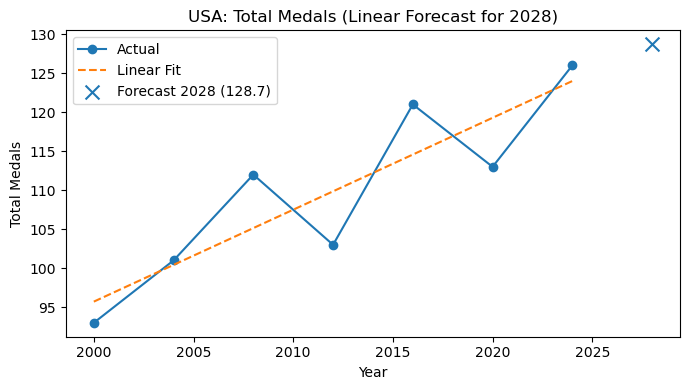

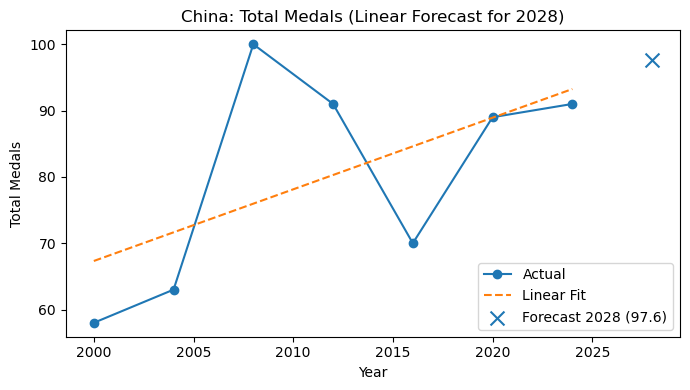

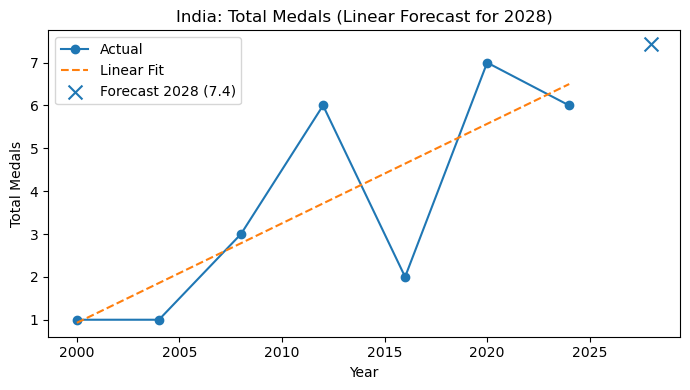

In [7]:
# Forecast USA/China/India Olympic medals for 2028
# - All countries: Linear Regression

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# -----------------------------
# 1) Data (edit these as needed)
# -----------------------------
years = np.array([2000, 2004, 2008, 2012, 2016, 2020, 2024])

data = pd.DataFrame({
    "Year": years,
    "USA":   [93, 101, 112, 103, 121, 113, 126],
    "China": [58,  63, 100,  91,  70,  89,  91],
    "India": [1,   1,   3,   6,   2,   7,   6],
}).set_index("Year")

forecast_year = np.array([[2028]])  # year to predict

# --------------------------------
# 2) Helper for fitting/predicting
# --------------------------------
def fit_linear_and_predict(y_vals, x_vals=years):
    """Fit linear regression and return fitted values + 2028 forecast."""
    X = x_vals.reshape(-1, 1)
    model = LinearRegression().fit(X, y_vals)
    fitted = model.predict(X)
    y_2028 = model.predict(forecast_year)[0]
    return fitted, float(y_2028)

# -----------------------------
# 3) Fit models and get forecasts
# -----------------------------
results = {}
fitted_curves = {}

for country in data.columns:
    fitted, forecast = fit_linear_and_predict(data[country].values)
    results[country] = forecast
    fitted_curves[country] = fitted

# -----------------------------
# 4) Print forecast summary table
# -----------------------------
forecast_df = (
    pd.Series(results, name="Forecast_Medals_2028")
    .round(2)
    .to_frame()
    .sort_index()
)
print("\n=== LA 2028 Medal Forecasts (Linear Models) ===")
print(forecast_df)

# -----------------------------
# 5) Plot: one chart per country
# -----------------------------
def plot_country(country, fitted, forecast_value):
    plt.figure(figsize=(7, 4))
    plt.plot(years, data[country].values, marker='o', label="Actual")
    plt.plot(years, fitted, label="Linear Fit", linestyle="--")
    plt.scatter([2028], [forecast_value], marker='x', s=100, label=f"Forecast 2028 ({forecast_value:.1f})")
    plt.title(f"{country}: Total Medals (Linear Forecast for 2028)")
    plt.xlabel("Year")
    plt.ylabel("Total Medals")
    plt.legend()
    plt.tight_layout()
    plt.show()

for country in data.columns:
    plot_country(country, fitted_curves[country], results[country])




=== LA 2028 Medal Forecasts (degree 2 vs 3) ===
              Forecast_Medals_2028
China_deg2                   76.14
China_deg3                  112.14
India_linear                  8.57
USA_deg2                    126.86
USA_deg3                    136.86


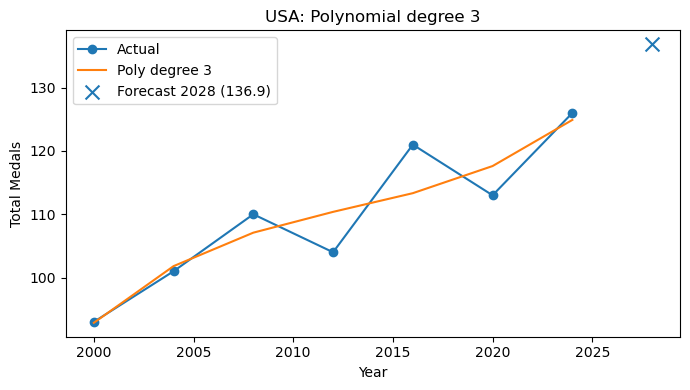

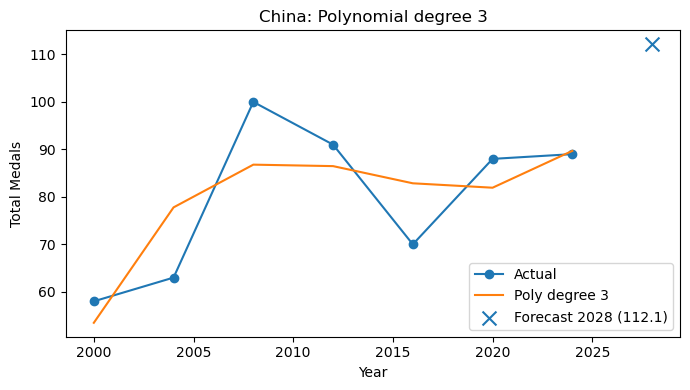

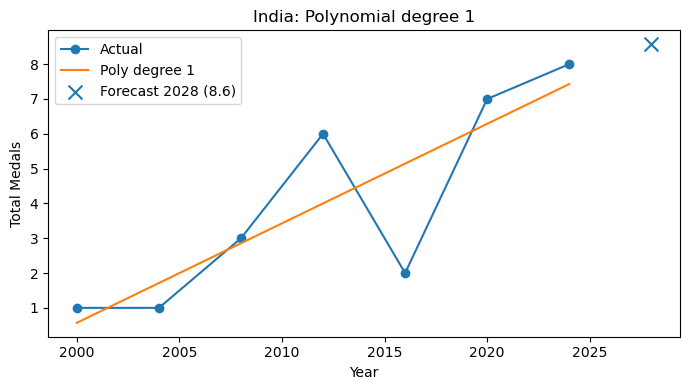

In [3]:
# Forecast USA/China/India Olympic medals for 2028
# - USA, China: Polynomial (degree 3)
# - India: Linear

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# -----------------------------
# 1) Data (edit these as needed)
# -----------------------------
years = np.array([2000, 2004, 2008, 2012, 2016, 2020, 2024])

data = pd.DataFrame({
    "Year": years,
    "USA":   [93, 101, 110, 104, 121, 113, 126],
    "China": [58,  63, 100,  91,  70,  88,  89],
    "India": [1,   1,   3,   6,   2,   7,   8],
}).set_index("Year")

forecast_year = np.array([[2028]])

# --------------------------------
# 2) Helper functions
# --------------------------------
def fit_poly_and_predict(y_vals, x_vals=years, degree=2):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(x_vals.reshape(-1, 1))
    model = LinearRegression().fit(X_poly, y_vals)
    fitted = model.predict(X_poly)
    y_2028 = model.predict(poly.transform(forecast_year))[0]
    return fitted, float(y_2028)

def fit_linear_and_predict(y_vals, x_vals=years):
    X = x_vals.reshape(-1, 1)
    model = LinearRegression().fit(X, y_vals)
    fitted = model.predict(X)
    y_2028 = model.predict(forecast_year)[0]
    return fitted, float(y_2028)

# -----------------------------
# 3) Fit models and get forecasts
# -----------------------------
results = {}

# USA: polynomial degree 2 & 3
_, usa_2028_deg2 = fit_poly_and_predict(data["USA"].values, degree=2)
usa_fit_deg3, usa_2028_deg3 = fit_poly_and_predict(data["USA"].values, degree=3)
results["USA_deg2"] = usa_2028_deg2
results["USA_deg3"] = usa_2028_deg3

# China: polynomial degree 2 & 3
_, chn_2028_deg2 = fit_poly_and_predict(data["China"].values, degree=2)
chn_fit_deg3, chn_2028_deg3 = fit_poly_and_predict(data["China"].values, degree=3)
results["China_deg2"] = chn_2028_deg2
results["China_deg3"] = chn_2028_deg3

# India: linear
ind_fit, ind_2028 = fit_linear_and_predict(data["India"].values)
results["India_linear"] = ind_2028

# -----------------------------
# 4) Print forecast summary
# -----------------------------
forecast_df = (
    pd.Series(results, name="Forecast_Medals_2028")
    .round(2)
    .to_frame()
    .sort_index()
)
print("\n=== LA 2028 Medal Forecasts (degree 2 vs 3) ===")
print(forecast_df)

# -----------------------------
# 5) Plot the degree-3 fits
# -----------------------------
def plot_country(country, fitted, forecast_value, degree):
    plt.figure(figsize=(7, 4))
    plt.plot(years, data[country].values, marker='o', label="Actual")
    plt.plot(years, fitted, label=f"Poly degree {degree}")
    plt.scatter([2028], [forecast_value], marker='x', s=100,
                label=f"Forecast 2028 ({forecast_value:.1f})")
    plt.title(f"{country}: Polynomial degree {degree}")
    plt.xlabel("Year")
    plt.ylabel("Total Medals")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_country("USA", usa_fit_deg3, usa_2028_deg3, degree=3)
plot_country("China", chn_fit_deg3, chn_2028_deg3, degree=3)
plot_country("India", ind_fit, ind_2028, degree=1)



=== LA 2028 Medal Forecasts (Linear Models) ===
       Forecast_Medals_2028
USA                  128.71
China                 97.57
India                  7.43


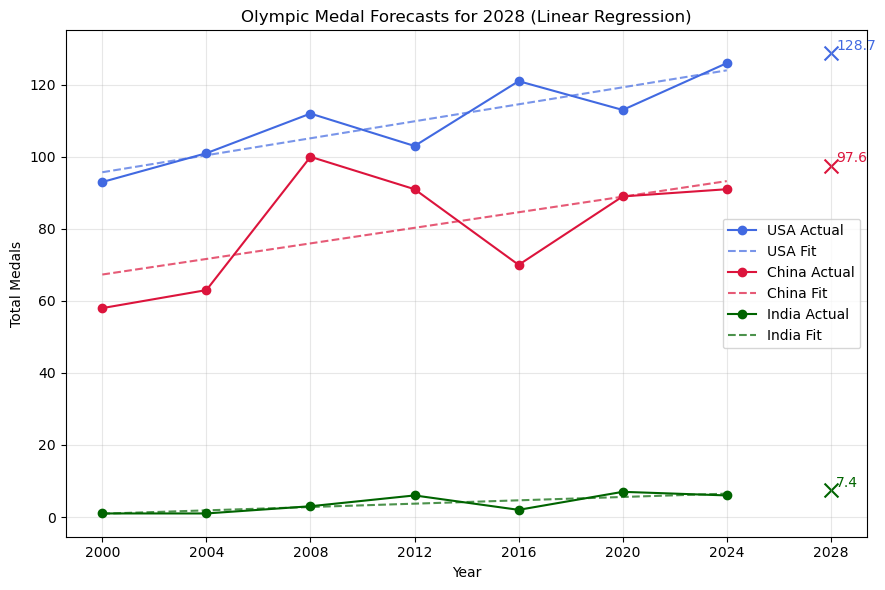

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# -----------------------------
# 1) Data
# -----------------------------
years = np.array([2000, 2004, 2008, 2012, 2016, 2020, 2024])

data = pd.DataFrame({
    "Year": years,
    "USA":   [93, 101, 112, 103, 121, 113, 126],
    "China": [58,  63, 100,  91,  70,  89,  91],
    "India": [1,   1,   3,   6,   2,   7,   6],
}).set_index("Year")

forecast_year = np.array([[2028]])

# -----------------------------
# 2) Fit linear regression for each
# -----------------------------
def fit_linear_and_predict(y_vals, x_vals=years):
    X = x_vals.reshape(-1, 1)
    model = LinearRegression().fit(X, y_vals)
    fitted = model.predict(X)
    y_2028 = model.predict(forecast_year)[0]
    return fitted, float(y_2028), model

results = {}
fitted_curves = {}
models = {}

for country in data.columns:
    fitted, forecast, model = fit_linear_and_predict(data[country].values)
    results[country] = forecast
    fitted_curves[country] = fitted
    models[country] = model

forecast_df = pd.Series(results, name="Forecast_Medals_2028").round(2).to_frame()
print("\n=== LA 2028 Medal Forecasts (Linear Models) ===")
print(forecast_df)

# -----------------------------
# 3) Combined plot
# -----------------------------
plt.figure(figsize=(9, 6))

colors = {"USA": "royalblue", "China": "crimson", "India": "darkgreen"}

for country in data.columns:
    # Plot actual values
    plt.plot(data.index, data[country], 'o-', color=colors[country], label=f"{country} Actual")
    # Plot fitted line
    plt.plot(data.index, fitted_curves[country], '--', color=colors[country], alpha=0.7, label=f"{country} Fit")
    # Plot 2028 forecast point
    plt.scatter(2028, results[country], color=colors[country], marker='x', s=100)
    plt.text(2028 + 0.2, results[country] + 1, f"{results[country]:.1f}", color=colors[country], fontsize=10)

plt.title("Olympic Medal Forecasts for 2028 (Linear Regression)")
plt.xlabel("Year")
plt.ylabel("Total Medals")
plt.xticks(np.append(years, 2028))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
